# Posterior for S. aureus local recombination rate and mutation rate using SBI

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
import seaborn as sns
from Bio import Phylo
import torch
from torch.distributions import Uniform
import sbi
from sbi.utils.user_input_checks import MultipleIndependent
from sbi.inference import NPE_C
from sbi.analysis import plot_summary
import sys
sys.path.append('../pysimARG')
from discrete_uniform import DiscreteUniform

torch_device = "cpu"

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load simulation data

Load staph gene data and clonal tree.

In [2]:
# Load phylo tree and convert to ClonalTree format
phylo_tree = Phylo.read("../data/staph/saureus_clonal.nwk", "newick")
Phylo.draw_ascii(phylo_tree)

                                                                   , C1139
                                                                  ,|
                                                                  |, C9658
                                                                  ||
                                                                  |, C1282
                                                                  ||
                      ____________________________________________|, C1280
                     |                                            ||
                     |                                            || C1080
                     |                                            |
                     |                                            |_ C1079
                     |                                            |
                     |                                            , C1147
                     |                                          

In [3]:
x_obs_df = pd.read_csv("../data/staph/core_gene_summary_stats.csv", index_col=0)
x_obs_np = x_obs_df.to_numpy()
x_obs_torch = torch.tensor(x_obs_np, device=torch_device)
x_obs_torch = x_obs_torch.to(torch.float32)
x_obs_torch.shape, x_obs_torch.dtype

(torch.Size([1983, 46]), torch.float32)

### Delete observations with no signal

In [4]:
no_signal_id = np.where(x_obs_np[:, 33] == 0)[0]
no_signal_id.shape, no_signal_id[:10]

((18,), array([ 137,  140,  236,  657,  659,  767,  773, 1036, 1485, 1497]))

In [5]:
x_obs_np = np.delete(x_obs_np, no_signal_id, axis=0)
x_obs_torch = torch.tensor(x_obs_np, device=torch_device)
x_obs_torch = x_obs_torch.to(torch.float32)
x_obs_np.shape, x_obs_torch.shape, x_obs_torch.dtype

((1965, 46), torch.Size([1965, 46]), torch.float32)

## Load simulation data

In [6]:
theta1 = np.loadtxt('../data/staph/ClonalOrigin_sim/change_theta/theta1.csv', delimiter=",")
x1 = np.loadtxt('../data/staph/ClonalOrigin_sim/change_theta/x1.csv', delimiter=",")

theta2 = np.loadtxt('../data/staph/ClonalOrigin_sim/change_theta/theta2.csv', delimiter=",")
x2 = np.loadtxt('../data/staph/ClonalOrigin_sim/change_theta/x2.csv', delimiter=",")

theta3 = np.loadtxt('../data/staph/ClonalOrigin_sim/change_theta/theta3.csv', delimiter=",")
x3 = np.loadtxt('../data/staph/ClonalOrigin_sim/change_theta/x3.csv', delimiter=",")

theta4 = np.loadtxt('../data/staph/ClonalOrigin_sim/change_theta/theta4.csv', delimiter=",")
x4 = np.loadtxt('../data/staph/ClonalOrigin_sim/change_theta/x4.csv', delimiter=",")

theta5 = np.loadtxt('../data/staph/ClonalOrigin_sim/change_theta/theta5.csv', delimiter=",")
x5 = np.loadtxt('../data/staph/ClonalOrigin_sim/change_theta/x5.csv', delimiter=",")

x = np.vstack([x1, x2, x3, x4, x5])
theta = np.vstack([theta1, theta2, theta3, theta4, theta5])

print(theta.shape, x.shape)

(50000, 3) (50000, 46)


In [7]:
theta = torch.tensor(theta, device=torch_device)
theta = theta.to(torch.float32)
theta_numpy = theta.cpu().numpy()

x = torch.tensor(x, device=torch_device)
x = x.to(torch.float32)
x_numpy = x.cpu().numpy()

### Find out-of-range observations

In [8]:
ignore_indices = []
no_segregation = []
out_stats = dict()
for i in range(x_obs_torch.shape[0]):
    ignore_i = False
    out_index = []
    for j in range(46):
        max_j = torch.max(x[:, j])
        min_j = torch.min(x[:, j])
        obs_j = x_obs_torch[i, j]
        if obs_j < min_j or obs_j > max_j:
            ignore_i = True
            out_index.append(j)
        if j == 33 and obs_j == 0:
            no_segregation.append(i)
    if ignore_i or torch.isnan(x_obs_torch[i, :]).any():
        print(f"Observation {i} is outside the range of simulated data.")
        ignore_indices.append(i)
        out_stats[i] = out_index

Observation 207 is outside the range of simulated data.
Observation 459 is outside the range of simulated data.
Observation 1233 is outside the range of simulated data.
Observation 1306 is outside the range of simulated data.
Observation 1322 is outside the range of simulated data.
Observation 1416 is outside the range of simulated data.
Observation 1807 is outside the range of simulated data.


In [9]:
len(ignore_indices), len(no_segregation), len(out_stats)

(7, 0, 7)

In [10]:
out_index_all = []
for i in range(len(ignore_indices)):
    idx = ignore_indices[i]
    out_index_all += out_stats[idx]

In [11]:
from collections import Counter

integer_counts = Counter(out_index_all)

In [12]:
for i in range(32):
    print(f"Index {i}: {integer_counts[i]}")

Index 0: 0
Index 1: 0
Index 2: 0
Index 3: 0
Index 4: 0
Index 5: 0
Index 6: 0
Index 7: 0
Index 8: 0
Index 9: 0
Index 10: 0
Index 11: 0
Index 12: 0
Index 13: 0
Index 14: 0
Index 15: 0
Index 16: 0
Index 17: 0
Index 18: 0
Index 19: 0
Index 20: 0
Index 21: 0
Index 22: 0
Index 23: 0
Index 24: 1
Index 25: 1
Index 26: 0
Index 27: 0
Index 28: 2
Index 29: 0
Index 30: 0
Index 31: 0


In [13]:
for i in range(32, 46):
    print(f"Index {i}: {integer_counts[i]}")

Index 32: 0
Index 33: 0
Index 34: 0
Index 35: 0
Index 36: 0
Index 37: 0
Index 38: 0
Index 39: 0
Index 40: 0
Index 41: 0
Index 42: 0
Index 43: 3
Index 44: 0
Index 45: 0


Drop columns for exact LD and G4 values

In [14]:
drop_columns = list(range(0, 8)) + list(range(16, 32))
len(drop_columns), drop_columns

(24,
 [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31])

In [15]:
x_drop = x.clone()
x_drop = x_drop[:, [i for i in range(x.shape[1]) if i not in drop_columns]]
x_drop_numpy = x_drop.cpu().numpy()
x_drop.shape, x_drop_numpy.shape

(torch.Size([50000, 22]), (50000, 22))

## NPE

### Create prior to pass range knowledge to NPE

In [17]:
prior_rho = Uniform(low=torch.tensor([0.0]), high=torch.tensor([0.1]))
prior_theta = Uniform(low=torch.tensor([0.0]), high=torch.tensor([0.02]))
prior_L = DiscreteUniform(low=torch.tensor([20.0]), high=torch.tensor([10000.0]))

prior = MultipleIndependent(
    dists=[prior_rho, prior_theta, prior_L],
    validate_args=False,
    device=torch_device
)

In [18]:
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference = NPE_C(prior=prior, density_estimator="nsf", device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [19]:
density_estimator = inference.append_simulations(theta, x_drop).train(
    max_num_epochs=500, learning_rate=learning_rate
)
posterior = inference.build_posterior(density_estimator)

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\sbi\inference\trainers\npe\npe_base.py:196: UserWarning: Data has extreme outliers in dimension(s) [0, 1, 4, 5, 8, 12, 14, 15, 17, 18, 19, 20] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 120 epochs.

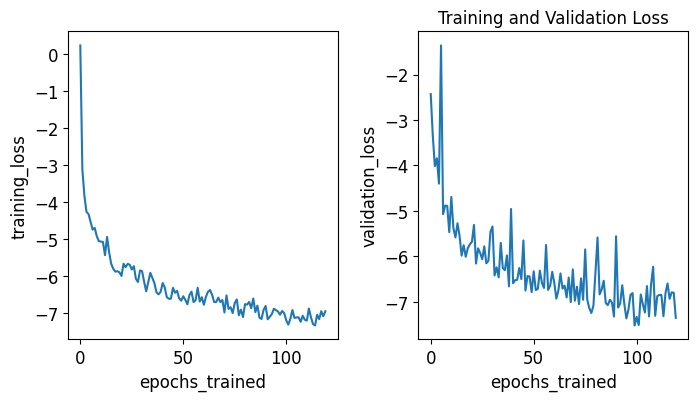

In [20]:
fig, axes = plot_summary(
    inference, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

### Save the trained NPE

In [21]:
save_path = "../data/staph/trained_npe_density_estimator_drop.pt"

torch.save(
    {
        "density_estimator": density_estimator,
        "prior": prior,
        "sbi_version": sbi.__version__,
        "learning_rate": learning_rate,
        "max_num_epochs": 500,
    },
    save_path,
)

### NPE in log-scale

In [16]:
theta_log = theta.clone()
theta_log[:, 0] = torch.log(theta_log[:, 0])
theta_log[:, 1] = torch.log(theta_log[:, 1])
theta_log_numpy = theta_log.cpu().numpy()
theta_log_numpy.shape, theta_numpy.shape

((50000, 3), (50000, 3))

In [17]:
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference_log = NPE_C(density_estimator="nsf", device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [18]:
density_estimator_log = inference_log.append_simulations(theta_log, x).train(
    max_num_epochs=500, learning_rate=learning_rate
)
posterior_log = inference_log.build_posterior(density_estimator_log)

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\sbi\inference\trainers\npe\npe_base.py:196: UserWarning: Data has extreme outliers in dimension(s) [0, 1, 2, 3, 4, 5, 8, 9, 12, 13, 17, 18, 19, 20, 21, 24, 25, 26, 27, 28, 29, 32, 36, 38, 39, 41, 42, 43, 44] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 188 epochs.

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\sbi\inference\potentials\posterior_based_potential.py:58: UserWarning: The passed prior has no support property, transform will be constructed from mean and std. If the passed prior is supposed to be bounded consider implementing the prior.support property.
  theta_transform = mcmc_transform(


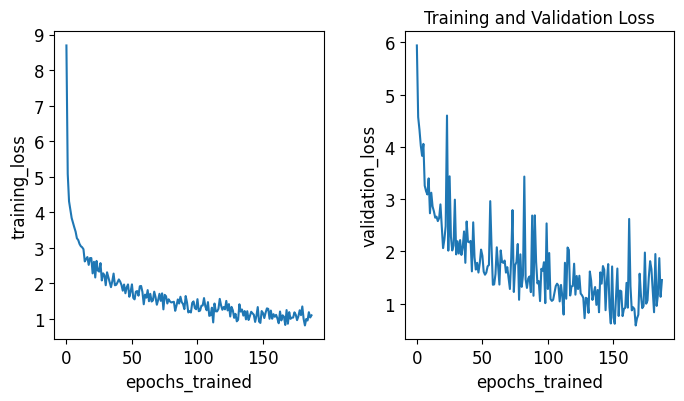

In [19]:
fig, axes = plot_summary(
    inference_log, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

### Save the trained NPE

In [20]:
save_path = "../data/staph/trained_npe_density_estimator_log.pt"

torch.save(
    {
        "density_estimator": density_estimator_log,
        "sbi_version": sbi.__version__,
        "learning_rate": learning_rate,
        "max_num_epochs": 500,
    },
    save_path,
)

### Plug in observation data to get posterior

In [21]:
theta_post = np.full((x_obs_torch.shape[0], num_posterior_samples, 3), np.nan)
theta_post.shape

(1965, 1000, 3)

In [22]:
for i in range(x_obs_torch.shape[0]):
    theta_post_torch = posterior_log.sample((num_posterior_samples,), x=x_obs_torch[i, :],
                                            show_progress_bars=False, reject_outside_prior=False)
    theta_post[i, :, :] = theta_post_torch.cpu().detach().numpy()

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\nflows\transforms\lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\BatchLinearAlgebra.cpp:2196.)
  outputs, _ = torch.triangular_solve(


In [23]:
theta_post_median = np.median(theta_post, axis=1)
theta_post_median.shape

(1965, 3)

In [24]:
np.save("../data/staph/log_posterior_median.npy", theta_post_median)